# First scratches for sensitivity study


Library of plots:
- Time series of variable-means
- Profiles & Profile Heatmaps
- Domains
- Meteograms

## Necessary libraries

In [1]:
%matplotlib inline

# system libs
import os, sys, glob
import datetime

# array operators and netcdf datasets
import numpy as np
import xarray as xr
xr.set_options(keep_attrs=True)

# plotting
import pylab as plt
import seaborn as sns
sns.set_context('talk')

import matplotlib.dates as mdates
myFmt = mdates.DateFormatter('%H:%M')

# to have tools to format time
sys.path.append( '/work/bb1224/2024_MS-COURSE/tools/analysis' )
from tools import convert_timevec

#import warnings
#warnings.simplefilter("ignore")

## Open datasets, cut domain and format time

In [2]:
# Path
# Irenes experiment:
#sim_path = '/work/bb1376/user/irene/icon-build/experiments/cesar1-20240806-exp001'
# Own experiment:
sim_path = '/home/b/b383413/workspace/icon-build0/experiments/cesar1-20240806-exp001-T06-21'

In [3]:
# ICON simulations for 3 nests:
# 2D variables
ds_2dicon1 = xr.open_mfdataset(f'{sim_path}/2d_*_DOM01_ML_20240806T????00Z_regrid1km.nc')
ds_2dicon2 = xr.open_mfdataset(f'{sim_path}/2d_*_DOM02_ML_20240806T????00Z_regrid1km.nc')
ds_2dicon3 = xr.open_mfdataset(f'{sim_path}/2d_*_DOM03_ML_20240806T????00Z_regrid1km.nc')

# 3D variables
ds_3dicon1 = xr.open_mfdataset(f'{sim_path}/3d_full_base_DOM01_ML_20240806T????00Z_regrid1km.nc')
ds_3dicon2 = xr.open_mfdataset(f'{sim_path}/3d_full_base_DOM02_ML_20240806T????00Z_regrid1km.nc')
ds_3dicon3 = xr.open_mfdataset(f'{sim_path}/3d_full_base_DOM03_ML_20240806T????00Z_regrid1km.nc')


In [4]:
# Define dictionaries to store datasets
datasets2d = {
    "exp001 icon d1": ds_2dicon1,
    "exp001 icon d2": ds_2dicon2,
    "exp001 icon d3": ds_2dicon3,
}

datasets3d = {
    "exp001 icon d1": ds_3dicon1,
    "exp001 icon d2": ds_3dicon2,
    "exp001 icon d3": ds_3dicon3,
}

In [5]:
# Define Lindenberg coordinates:
lon_lind, lat_lind = 14.11845, 52.20967

# Define the spatial range over Lindenberg:
lat_min, lat_max = 51.85, 52.55    
lon_min, lon_max = 13.65, 14.55 

# Apply spatial selection to all datasets
for datasets in [datasets2d, datasets3d]:
    for name, ds in datasets.items():
        datasets[name] = ds.sel(lat=slice(lat_min, lat_max), lon=slice(lon_min, lon_max))


In [6]:
# Format time 
for name, ds in datasets2d.items():
    ds['time'] = convert_timevec(ds.time.data)
for name, ds in datasets3d.items():
    ds['time'] = convert_timevec(ds.time.data)

## Check for relevant variables

In [7]:
ds_2dicon1


<xarray.Dataset>
Dimensions:        (time: 181, lon: 801, lat: 501, plev: 1, bnds: 2, plev_2: 1,
                    plev_3: 1, height: 1, height_2: 1, depth: 8, depth_2: 9,
                    depth_3: 1)
Coordinates:
  * time           (time) float64 2.024e+07 2.024e+07 ... 2.024e+07 2.024e+07
  * lon            (lon) float64 10.0 10.01 10.02 10.03 ... 17.98 17.99 18.0
  * lat            (lat) float64 50.0 50.01 50.02 50.03 ... 54.98 54.99 55.0
  * plev           (plev) float64 0.0
  * plev_2         (plev_2) float64 400.0
  * plev_3         (plev_3) float64 800.0
  * height         (height) float64 2.0
  * height_2       (height_2) float64 10.0
  * depth          (depth) float64 5.0 20.0 60.0 ... 1.62e+03 4.86e+03 1.458e+04
  * depth_2        (depth_2) float64 0.0 5.0 20.0 ... 4.86e+03 1.458e+04
  * depth_3        (depth_3) float64 0.0
Dimensions without coordinates: bnds
Data variables: (12/47)
    plev_bnds      (time, plev, bnds) float64 dask.array<chunksize=(12, 1, 2), meta=np.ndarray>
    plev_2_bnds    (time, plev_2, bnds) float64 dask.array<chunksize=(12, 1, 2), meta=np.ndarray>
    plev_3_bnds    (time, plev_3, bnds) float64 dask.array<chunksize=(12, 1, 2), meta=np.ndarray>
    tqv_dia        (time, lat, lon) float32 dask.array<chunksize=(12, 501, 801), meta=np.ndarray>
    tqc_dia        (time, lat, lon) float32 dask.array<chunksize=(12, 501, 801), meta=np.ndarray>
    tqi_dia        (time, lat, lon) float32 dask.array<chunksize=(12, 501, 801), meta=np.ndarray>
    ...             ...
    sou_s          (time, lat, lon) float32 dask.array<chunksize=(12, 501, 801), meta=np.ndarray>
    thb_s          (time, lat, lon) float32 dask.array<chunksize=(12, 501, 801), meta=np.ndarray>
    thu_s          (time, lat, lon) float32 dask.array<chunksize=(12, 501, 801), meta=np.ndarray>
    sob_t          (time, lat, lon) float32 dask.array<chunksize=(12, 501, 801), meta=np.ndarray>
    sod_t          (time, lat, lon) float32 dask.array<chunksize=(12, 501, 801), meta=np.ndarray>
    thb_t          (time, lat, lon) float32 dask.array<chunksize=(12, 501, 801), meta=np.ndarray>
Attributes:
    CDI:          Climate Data Interface version 2.4.0 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    institution:  Max Planck Institute for Meteorology/Deutscher Wetterdienst
    title:        ICON simulation
    source:       version: 2024.10; revision: icon-2024.10-public-0-ga1324166...
    history:      /home/b/b383413/workspace/icon-build/bin/icon at 20250424 1...
    references:   see MPIM/DWD publications
    comment:      Daniel Kloster (b383413) on l10668 (Linux 4.18.0-513.24.1.e...

maybe relevant variables: cloud fraction, lwp?, reff_qc?

- cloud fractions in units % :
    - clct : total cloud cover
    - clch : high level clouds
    - clcm : mid level clouds
    - clcl : low level clouds
 
- LWP (liquid water path?) in units kg m**-2:
    - tqc_dia : total column integrated cloud water (diagnostic)
    - tqv_dia : total column integrated water vapour (diagnostic)
     
- radiative fluxes at TOA in units W m-2:
  - sob_t : shortwave net flux at TOA
  - sod_t : downward shortwave flux at TOA
  - thb_t : thermal net flux at TOA

## Plot functions

### Time Series of Variable means

In [8]:
def plot_variable_mean(datasets, variable, title, mean_dims=('lat', 'lon')):
    """
    Plots the mean of a specified variable over given dimensions for multiple datasets.
    
    Parameters:
        datasets (dict): Dictionary where keys are dataset names and values are xarray datasets.
        variable (str): The name of the variable to plot.
        title (str): Title for the plot.
        mean_dims (tuple): Dimensions over which to compute the mean.
    """
    plt.figure(figsize=(10, 6))
    
    for name, ds in datasets.items():
        if variable in ds:
            var_mean = ds[variable].mean(dim=mean_dims)
            var_mean.plot(label=name)
        else:
            print(f"Warning: Variable '{variable}' not found in dataset '{name}'")
    
    plt.title(title)
    plt.legend()
    plt.show()


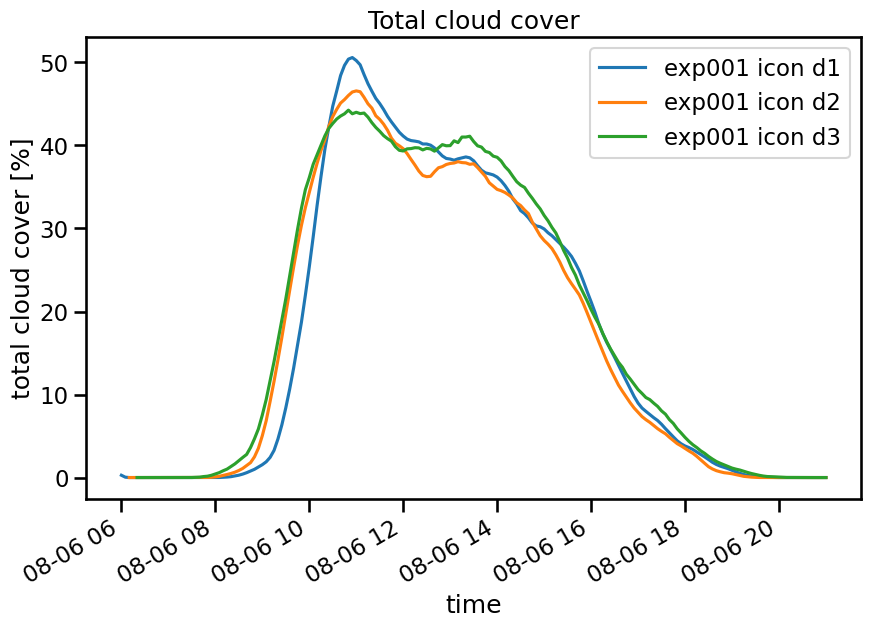

In [9]:
plot_variable_mean(datasets2d, 'clct', "Total cloud cover", mean_dims=('lat', 'lon'))

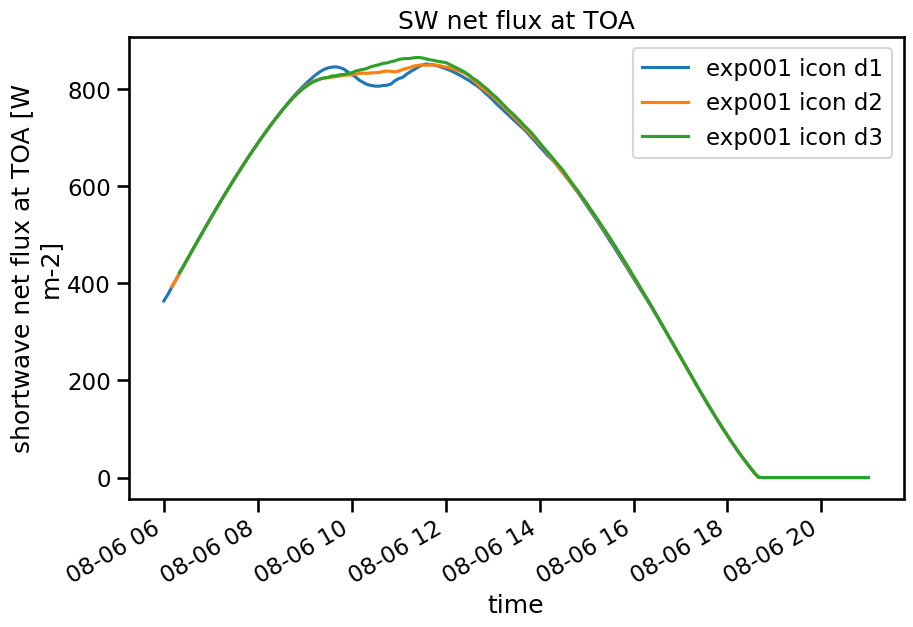

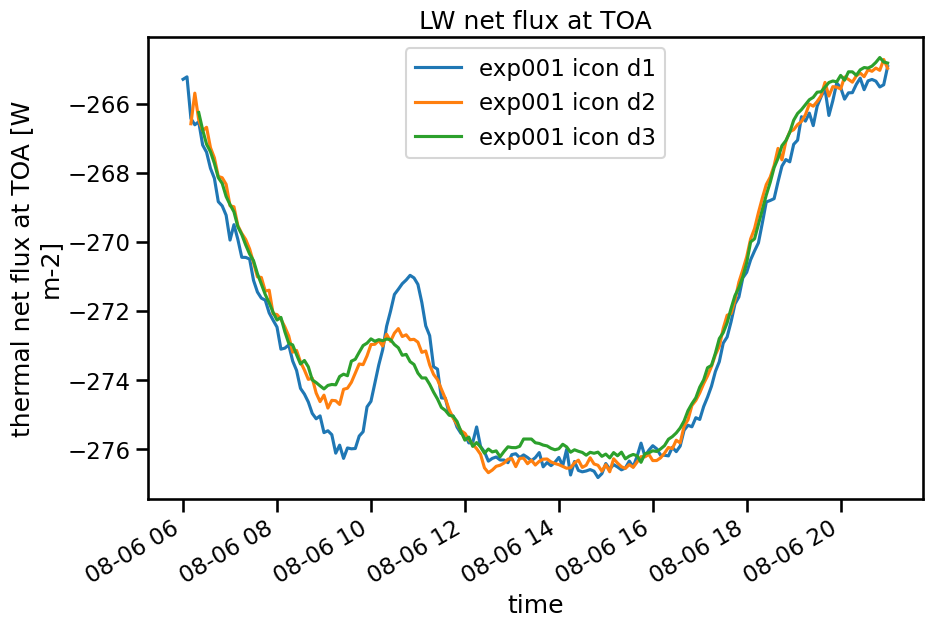

In [10]:
plot_variable_mean(datasets2d, 'sob_t', "SW net flux at TOA", mean_dims=('lat', 'lon'))
plot_variable_mean(datasets2d, 'thb_t', "LW net flux at TOA", mean_dims=('lat', 'lon'))

### Time Series of Variable means for a selected timerange

In [11]:
def plot_variable_mean_timerange(datasets, variable, title, mean_dims=('lat', 'lon'),time_range=None):
    """
    Plots the mean of a specified variable over given dimensions for multiple datasets.
    
    Parameters:
        datasets (dict): Dictionary where keys are dataset names and values are xarray datasets.
        variable (str): The name of the variable to plot.
        title (str): Title for the plot.
        mean_dims (tuple): Dimensions over which to compute the mean.
        time_range (tuple): Optional. A tuple of two datetime-like strings (start, end).(time_range=("2024-08-06T12:00", "2024-08-06T13:00"))
    """
    plt.figure(figsize=(10, 6))
    
    """for name, ds in datasets.items():
        if variable in ds:
            var_mean = ds[variable].mean(dim=mean_dims)
            var_mean.plot(label=name)
        else:
            print(f"Warning: Variable '{variable}' not found in dataset '{name}'")
    """
    for name, ds in datasets.items():
        if variable in ds:
            var = ds[variable]
            
            # Filter by time if specified
            if time_range is not None:
                start, end = time_range
                var = var.sel(time=slice(start, end))
            
            var_mean = var.mean(dim=mean_dims)
            var_mean.plot(label=name)
        else:
            print(f"Warning: Variable '{variable}' not found in dataset '{name}'")
    
    
    plt.title(title)
    plt.legend()
    plt.show()


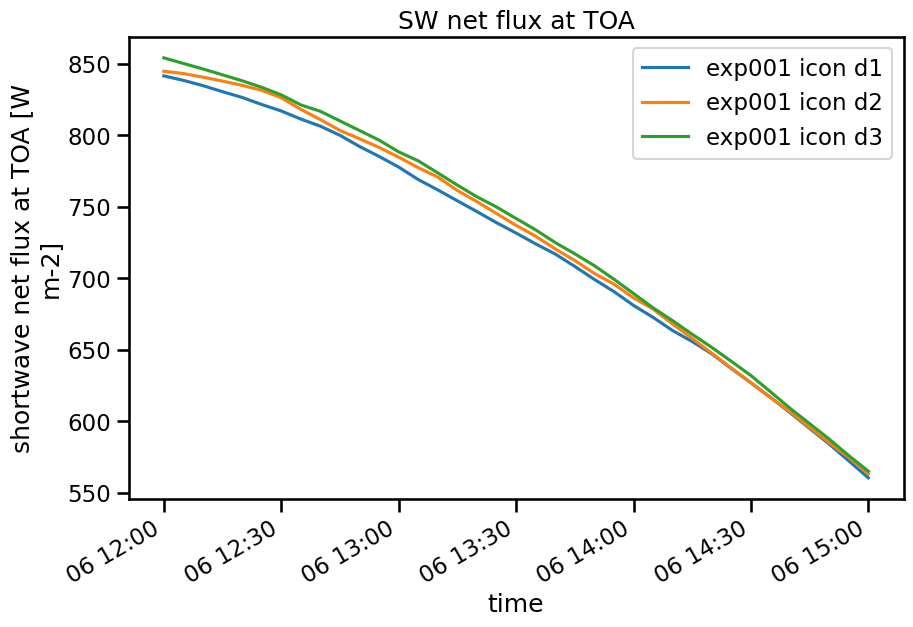

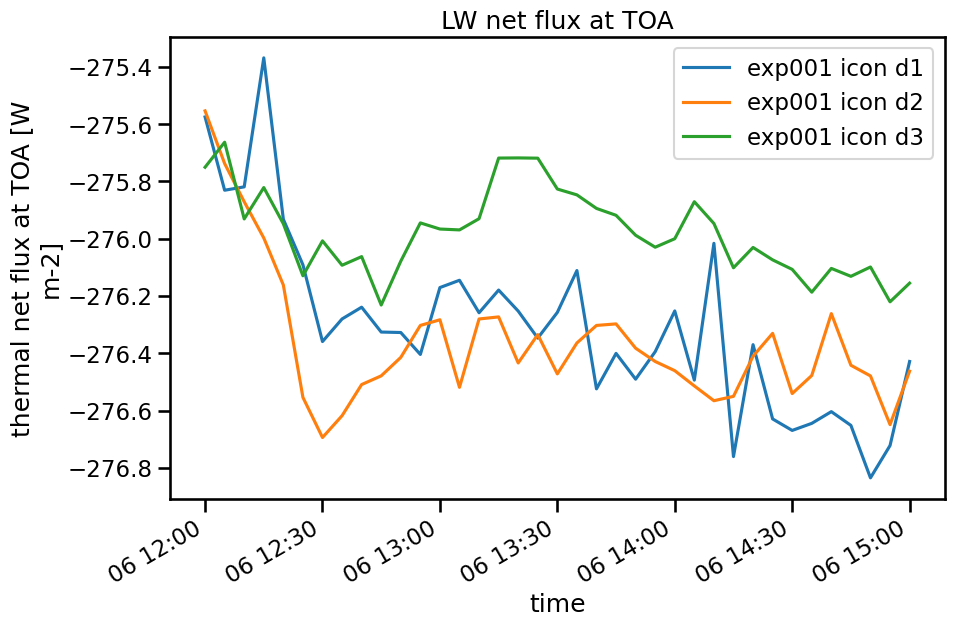

In [12]:
plot_variable_mean_timerange(datasets2d, 'sob_t', "SW net flux at TOA", mean_dims=('lat', 'lon'), time_range=("2024-08-06T12:00", "2024-08-06T15:00"))
plot_variable_mean_timerange(datasets2d, 'thb_t', "LW net flux at TOA", mean_dims=('lat', 'lon'), time_range=("2024-08-06T12:00", "2024-08-06T15:00"))

### Profiles

In [13]:
def plot_profile(datasets, variable, vert_dim, title, xlabel):
    """
    Plot a specified variable from multiple 3D datasets.

    Parameters:
    - datasets: Dictionary of 3D datasets, where the key is the dataset name and the value is the dataset.
    - variable: The variable in the dataset to plot (e.g., 'w').
    - vert_dim: Vertical coordinate name
    - title: Title of the plot.
    - xlabel: Label for the x-axis.
    """
    # Initialize a figure for plotting
    plt.figure(figsize=(6, 6))

    # Loop over datasets and plot
    for name, ds in datasets.items():
        # Calculate the mean of the specified variable over the given dimensions
        var_mean = ds[variable].mean(dim=('time', 'lat', 'lon'))
        
        # Plot the variable against vertical dim
        plt.plot(var_mean.values, ds[vert_dim].values, label=name)
        sns.despine()
    
    # Invert the y-axis because ICON vertical levels start from top
    plt.gca().invert_yaxis()
    
    # Add plot details
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel('Model level')
    plt.legend()
    plt.show()

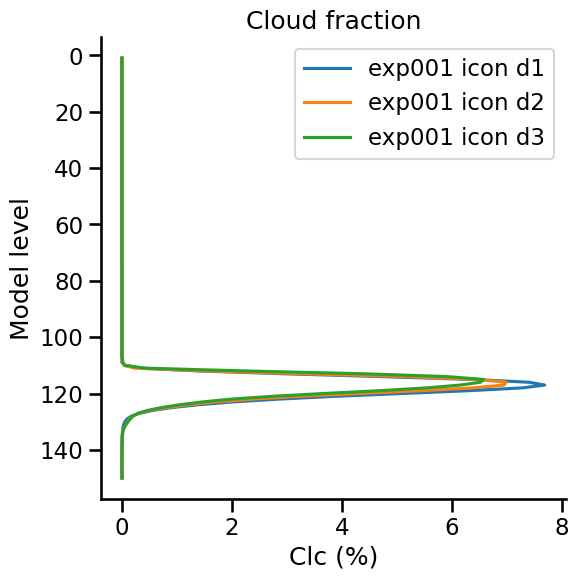

In [14]:
plot_profile(datasets3d, 'clc', 'height', "Cloud fraction", "Clc (%)")

### Profile Heatmap

In [15]:
def plot_profile_heatmap(datasets, variable, vert_dim, title_prefix, cbar_label):
    """
    Plot heatmaps of a specified variable from multiple 3D datasets with an inverted y-axis.
    
    Parameters:
    - datasets: Dictionary of 3D datasets, where the key is the dataset name and the value is the dataset.
    - variable: The variable in the dataset to plot (e.g., 'w').
    - vert_dim: Vertical coordinate name.
    - title_prefix: Prefix for the title of each subplot.
    - cbar_label: Label for the colorbar (e.g., 'm s**-1').
    """
    # Create a figure and axis for the plot
    fig, axes = plt.subplots(1, len(datasets), figsize=(18, 6), gridspec_kw={'wspace': 0.6})

    # Ensure axes is iterable for a single subplot case
    if len(datasets) == 1:
        axes = [axes]

    # Loop over the datasets and plot
    for ax, (name, ds) in zip(axes, datasets.items()):
        # Calculate the mean of the specified variable over the provided dimensions
        var_mean = ds[variable].mean(dim=('lat', 'lon'))
        
        # Plot the heatmap for each dataset
        heatmap = ax.pcolormesh(ds['time'], ds[vert_dim], var_mean.T, cmap='Spectral')

        # Invert the y-axis because ICON vertical levels start from top
        ax.invert_yaxis()

        # Customize the plot for each subplot
        ax.set_xlabel('Time', fontsize=12)
        ax.set_ylabel('Model level', fontsize=12)
        ax.set_title(f'{title_prefix} - {name}', fontweight='bold', fontsize=14)
        ax.tick_params(axis='x', labelrotation=30)
        
        # Add a colorbar for each subplot
        cbar = fig.colorbar(heatmap, ax=ax)
        cbar.set_label(cbar_label, fontsize=12)

    
    plt.show()

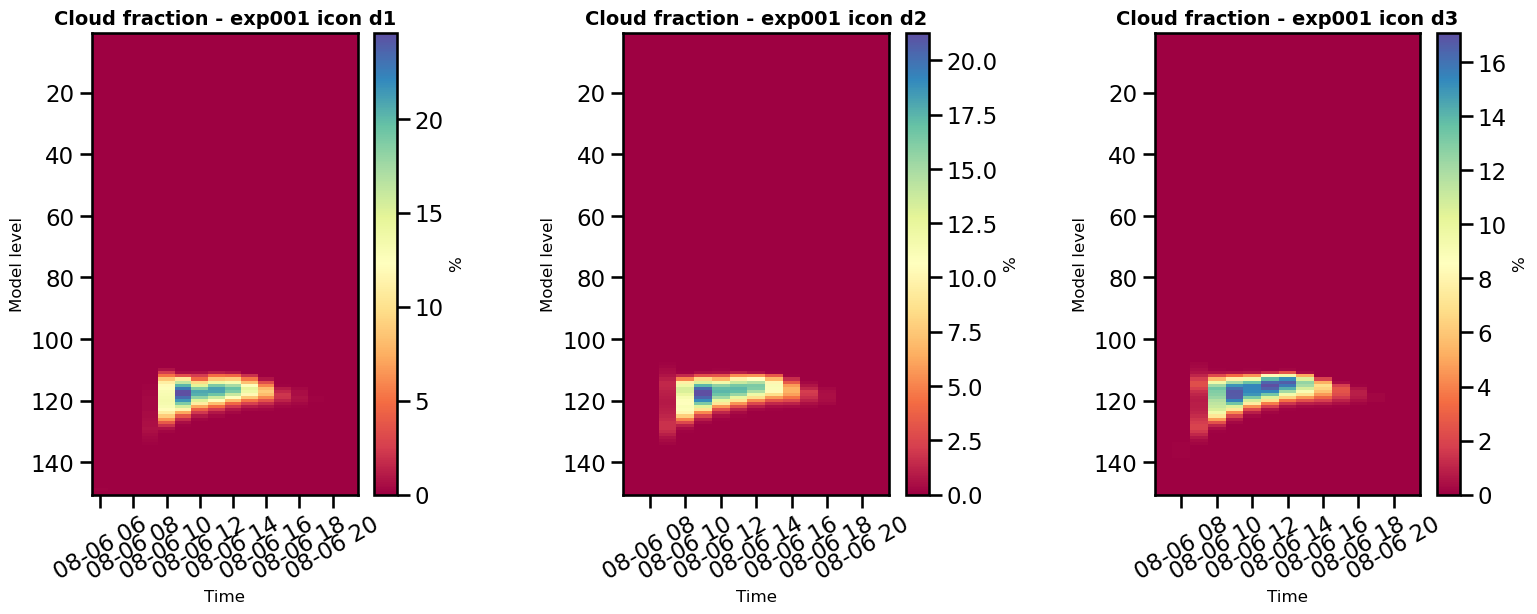

In [16]:
plot_profile_heatmap(datasets3d, 'clc', 'height', 'Cloud fraction', '%')

### Plot Domains

In [17]:
Dom1 = xr.open_mfdataset(f'{sim_path}/domain1_DOM01.nc')

In [18]:
Dom1

<xarray.Dataset>
Dimensions:                        (cell: 142720, vertex: 71847, edge: 214566,
                                    nv: 3, nc: 2, ne: 6, no: 4, max_chdom: 1,
                                    cell_grf: 14, edge_grf: 24, vert_grf: 13)
Coordinates:
    clon                           (cell) float64 dask.array<chunksize=(142720,), meta=np.ndarray>
    clat                           (cell) float64 dask.array<chunksize=(142720,), meta=np.ndarray>
    vlon                           (vertex) float64 dask.array<chunksize=(71847,), meta=np.ndarray>
    vlat                           (vertex) float64 dask.array<chunksize=(71847,), meta=np.ndarray>
    elon                           (edge) float64 dask.array<chunksize=(214566,), meta=np.ndarray>
    elat                           (edge) float64 dask.array<chunksize=(214566,), meta=np.ndarray>
Dimensions without coordinates: cell, vertex, edge, nv, nc, ne, no, max_chdom,
                                cell_grf, edge_grf, vert_grf
Data variables: (12/51)
    cartesian_x_vertices           (vertex) float64 dask.array<chunksize=(71847,), meta=np.ndarray>
    cartesian_y_vertices           (vertex) float64 dask.array<chunksize=(71847,), meta=np.ndarray>
    cartesian_z_vertices           (vertex) float64 dask.array<chunksize=(71847,), meta=np.ndarray>
    cell_area                      (cell) float64 dask.array<chunksize=(142720,), meta=np.ndarray>
    dual_area                      (vertex) float64 dask.array<chunksize=(71847,), meta=np.ndarray>
    lon_cell_centre                (cell) float64 dask.array<chunksize=(142720,), meta=np.ndarray>
    ...                             ...
    end_idx_e                      (max_chdom, edge_grf) int32 dask.array<chunksize=(1, 24), meta=np.ndarray>
    refin_v_ctrl                   (vertex) int32 dask.array<chunksize=(71847,), meta=np.ndarray>
    start_idx_v                    (max_chdom, vert_grf) int32 dask.array<chunksize=(1, 13), meta=np.ndarray>
    end_idx_v                      (max_chdom, vert_grf) int32 dask.array<chunksize=(1, 13), meta=np.ndarray>
    parent_edge_index              (edge) int32 dask.array<chunksize=(214566,), meta=np.ndarray>
    parent_vertex_index            (vertex) int32 dask.array<chunksize=(71847,), meta=np.ndarray>
Attributes: (12/18)
    title:                ICON grid description
    institution:          Max Planck Institute for Meteorology/Deutscher Wett...
    source:               git@gitlab.dwd.de:fe1/routine/icontools, branch (no...
    number_of_grid_used:  99
    ICON_grid_file_uri:   
    centre:               78
    ...                   ...
    inverse_flattening:   0.0
    grid_level:           8
    grid_root:            19
    uuidOfParHGrid:       c6b12daa-91ad-6404-5b26-c1b6452a2a20
    uuidOfHGrid:          7fad9f84-2562-8608-875c-071c55c029c0
    global_grid:          0

In [19]:
datasets = {}
for i in range(1, 4):  # Loop through domain indices
    datasets[f'dom{i:02}'] = xr.open_mfdataset(f'{sim_path}/domain{i}*.nc')
    #datasets[f'extpar{i:02}'] = xr.open_mfdataset(f'{grid_path}/external*domain{i}*.nc')

In [20]:
# Create a dictionary to store the converted longitude and latitude
coords = {}

for i in range(1, 4):  # Loop over the domains
    # Read edge lon/lat in radians
    elon_rad = datasets[f'dom{i:02}']['elon']  # Center longitude in radians
    elat_rad = datasets[f'dom{i:02}']['elat']  # Center latitude in radians
    
    # Convert to degrees
    elon = np.rad2deg(elon_rad)
    elat = np.rad2deg(elat_rad)
    
    # Store in coordinates dictionary
    coords[f'domain{i}'] = {'elon': elon, 'elat': elat}

In [21]:
coords['domain1']['elat']

<xarray.DataArray 'elat' (edge: 214566)>
dask.array<rad2deg, shape=(214566,), dtype=float64, chunksize=(214566,), chunktype=numpy.ndarray>
Coordinates:
    elon     (edge) float64 dask.array<chunksize=(214566,), meta=np.ndarray>
    elat     (edge) float64 dask.array<chunksize=(214566,), meta=np.ndarray>
Dimensions without coordinates: edge
Attributes:
    units:          radian
    standard_name:  grid_latitude
    bounds:         elat_vertices

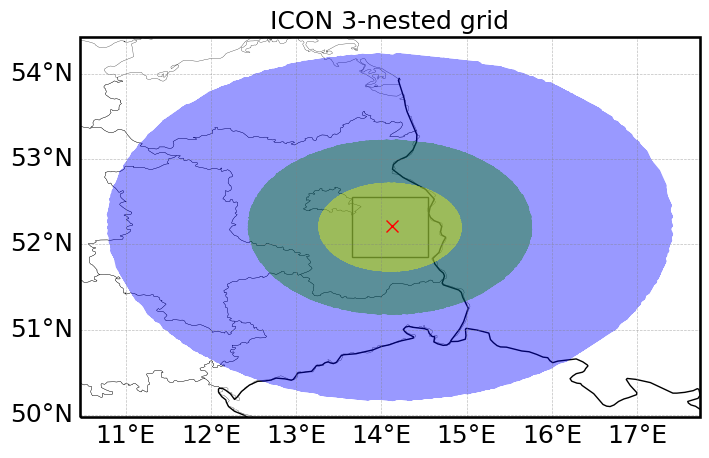

In [22]:
# plotting onto a map
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cartopy.io.shapereader as shpreader
from matplotlib.patches import Rectangle


#set up plot
plt.figure(figsize = (8,5))
ax = plt.axes(projection = ccrs.PlateCarree())

# Loop to plot domain borders with dynamic colors
colors = ['blue', 'green', 'yellow']
for i in range(1, 4):
    ax.plot( coords[f'domain{i}']['elon'],  coords[f'domain{i}']['elat'],  color=colors[i - 1], alpha=0.4, linewidth=2)

# read shape file for German states
exercise_path = '/work/bb1224/2024_MS-COURSE'
data_path = f'{exercise_path}/data'
shape_file = f'{data_path}/shapes/vg2500_bld.shp'
reader = shpreader.Reader(shape_file)
#  and create cartopy feature for German federal states border (that are not known to cartopy)
states_data = list(reader.geometries())
states = cfeature.ShapelyFeature(states_data, ccrs.PlateCarree())
# draw country borders
ax.add_feature(cfeature.BORDERS.with_scale('50m'), linewidth = 1)
# draw states borders
ax.add_feature(states, facecolor='none', edgecolor='black', linewidth = 0.2)


# Red cross over Lindenberg
ax.plot(lon_lind, lat_lind, marker='x', color='red', markersize=8)


# Define width and height from bounds
width = lon_max - lon_min
height = lat_max - lat_min
# Create rectangle with these bounds
rect = Rectangle(
    (lon_min, lat_min),    # Bottom-left corner (lon, lat)
    width,                 # Width in degrees
    height,                # Height in degrees
    linewidth=1,
    edgecolor='k',
    facecolor='none',      # Transparent fill
    alpha=1,
    transform=ccrs.PlateCarree()  # Coordinates in lon/lat
)
ax.add_patch(rect)

# Add gridlines and labels
gl = ax.gridlines(draw_labels=True, linewidth=0.5, color='gray', alpha=0.5, linestyle='--')
gl.top_labels = False  # Disable top labels
gl.right_labels = False  # Disable right labels

plt.title('ICON 3-nested grid')
plt.show()


### Meteograms

In [23]:
import pandas as pd

def plot_meteogram_timeseries(datasets, var_name, title, ylabel, lat, lon):
    """
    Plots a meteogram for a specific variable from multiple ICON datasets 
    at the nearest grid point to a given coordinate (lat/lon).
    
    Parameters:
    - datasets: dict of xarray Datasets
    - var_name: variable name (string)
    - title: plot title (string)
    - ylabel: y-axis label (string)
    - lat, lon: target coordinates (float)
    """
    fig, ax = plt.subplots(figsize=(10, 5))


    for i, (label, ds) in enumerate(datasets.items()):
        
        # Perform spatial selection without altering the original dataset
        ds_point = ds.sel(lat=lat, lon=lon, method="nearest")

        time = pd.to_datetime(ds_point["time"].values)
        data = ds_point[var_name].values

        ax.plot(time, data, label=label)
       
    ax.set_title(title)
    ax.set_ylabel(ylabel)
    ax.set_xlabel("Time")
    ax.legend()
    plt.xticks(rotation=45)
    plt.show()


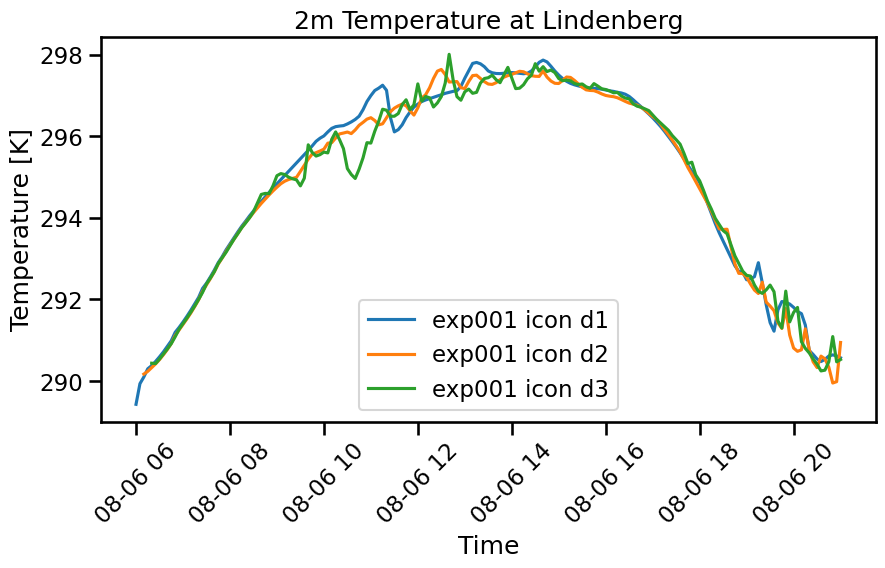

In [24]:
plot_meteogram_timeseries(
    datasets=datasets2d,
    var_name="t_2m",
    title="2m Temperature at Lindenberg",
    ylabel="Temperature [K]",
    lat=lat_lind,
    lon=lon_lind
)


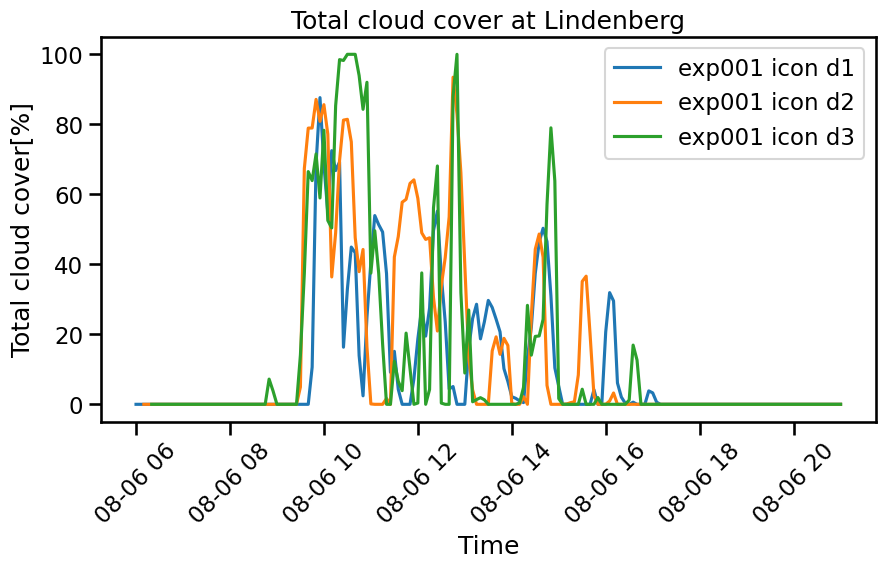

In [25]:
plot_meteogram_timeseries(
    datasets2d,
    var_name= 'clct',
    title="Total cloud cover at Lindenberg",
    ylabel="Total cloud cover[%]",
    lat=lat_lind,
    lon=lon_lind
)


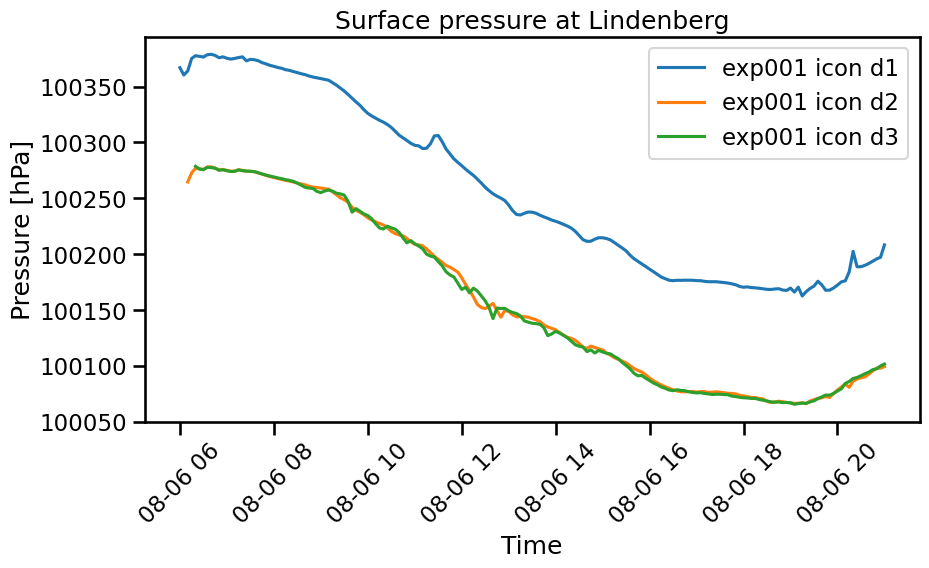

In [26]:
plot_meteogram_timeseries(datasets2d,'pres_sfc', "Surface pressure at Lindenberg", "Pressure [hPa]", lat=lat_lind,
    lon=lon_lind)

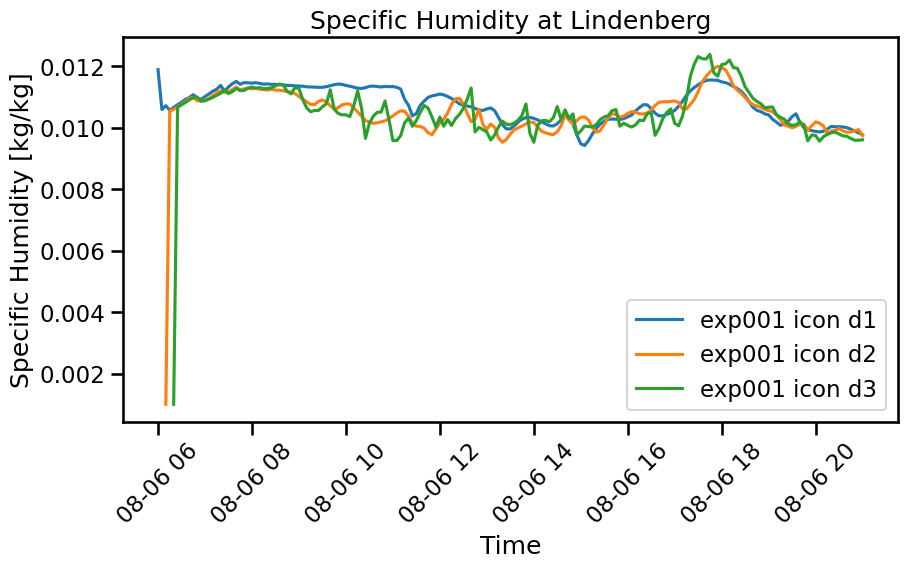

In [27]:
plot_meteogram_timeseries(datasets2d,'qv_s', "Specific Humidity at Lindenberg", "Specific Humidity [kg/kg]", lat=lat_lind,
    lon=lon_lind)